In [1]:
import ChessLens

from matplotlib import pyplot as plt
import numpy as np
import cv2

from Dataset.DataSetLoaders.ChessDataset import ChessDataset

/mnt/D/University/Thesis/.venv/lib/python3.13/site-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/mnt/D/University/Thesis/.venv/lib/python3.13/site-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=ResNet18_Weights.IMAGENET1K_V1`. You can also use `weights=ResNet18_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


In [2]:
dataset = ChessDataset(
    config={
        "img_size": (640,640)
    }
)
dataloader = ChessDataset.getLoader(dataset, batch_size=4, num_worders=0)

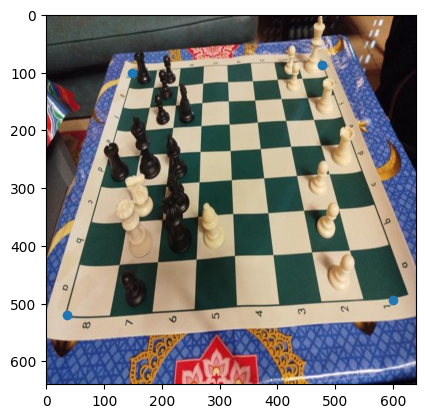

In [4]:
# for img, label in dataset:
    # _, H, W = img.shape
    # print(label)
    # plt.imshow(img.permute(1,2,0));
    # plt.scatter(label["corners"][:,0], label["corners"][:,1])

    # print(H, W)
    # break

img, _ = dataset[9]

# img = ChessLens.ChessLensImage("./Dataset/img_3.jpeg")
img = ChessLens.ChessLensImage(img)
img.detect_board()
_, H, W = img.img.shape
label = {
    "corners": img.board_detection
}

plt.imshow(img.img.permute(1,2,0));
plt.scatter(img.board_detection[:,0], img.board_detection[:,1]);

In [5]:
s = 0
cx = W/2
cy = H/2

In [34]:
# fx = 2739.79 * 640 / 2304
# fy = 2739.79 * 640/1728
fx = 2739.79 * W/4032
fy = 2739.79 * H/3024

K = np.array([
    [fx, s, cx],
    [0, fy, cy],
    [0,  0,  1]
]) # K: intrinsics of 3d -> 2d

In [35]:
cam_point = np.array([0,0,.5])
Z = cam_point[2]

r_val = 1/np.sqrt(2)
R_ = np.array([
    [1, 0, 0],
    [0, -r_val, -r_val],
    [0, r_val, -r_val],
])
t = (-R_) @ cam_point.reshape((3,1))
# t = np.array([
#     [0],
#     [-Z * r_val],
#     [Z * r_val]
# ])

R = np.concat([R_, t], axis=1)
R = np.concat([R, np.array([[0,0,0,1]])], axis=0) # R: extrinsics of World -> Camera

In [36]:
def from_3d_to_2d(points: np.ndarray, K: np.ndarray, R: np.ndarray):
    N = points.shape[0]
    points_ = np.concat([points, np.ones((N, 1))], axis=1)
    res_points = points_ @ R.T
    res_points = (res_points / res_points[:,[3]])[:, :3]
    res_points = res_points @ K.T
    res_points = (res_points/res_points[:, [2]])[:, :2]
    return res_points

def from_2d_to_3d(points: np.ndarray, K: np.ndarray, R: np.ndarray):
    N = points.shape[0]
    points_ = np.concat([points, np.ones((N, 1))], axis=1)
    res_points = points_ @ np.linalg.inv(K).T

    points_ = np.concat([res_points, np.ones((N, 1))], axis=1)
    res_points = points_ @ np.linalg.inv(R).T
    res_points = (res_points/res_points[:, [3]])[:, :3]

    return res_points

def trace_ray(directions: np.ndarray, cam_point: np.ndarray, Z_0: np.ndarray):
    N = directions.shape[0]
    if directions.shape[1] != 3 or len(directions.shape) != 2 \
        or cam_point.shape[0] != 3 or len(cam_point.shape) != 1 \
        or Z_0.shape[0] != N or len(Z_0.shape) != 1:
        raise Exception("Invalid input")
    
    t = ((Z_0-cam_point[2]) / (directions[:, 2] - cam_point[2]))
    p = cam_point + t.reshape(N, 1) * (directions - cam_point.reshape(1,3))
    return p

p = np.array([
    [1,2,3],
    [4,5,10]
])
print(p)
p1 = from_3d_to_2d(p, K, R)
print(p1)
p2 = from_2d_to_3d(p1, K, R)
print(p2)
p3 = trace_ray(p2, cam_point, np.array([3, 10]))
print(p3)

[[ 1  2  3]
 [ 4  5 10]]
[[    -910.05      5538.6]
 [    -226.69      2188.4]]
[[    -2.8284     -5.6569     -6.5711]
 [    -1.2571     -1.5713     -2.4856]]
[[          1           2           3]
 [          4           5          10]]


In [37]:
label["corners"]

tensor([[148., 101.],
        [478.,  86.],
        [600., 493.],
        [ 36., 520.]])

In [38]:
corners_3d = trace_ray(from_2d_to_3d(label["corners"].numpy(), K, R), cam_point, np.zeros((4)))
corners_3d

array([[   -0.44939,      1.1069,  5.5511e-17],
       [    0.43072,      1.1766,           0],
       [    0.35065,     0.27021,           0],
       [   -0.34335,     0.24354,  5.5511e-17]])

In [39]:
corners_up_2d = from_3d_to_2d(corners_3d, K, R)
corners_up_2d

array([[        148,         101],
       [        478,          86],
       [        600,         493],
       [         36,         520]])

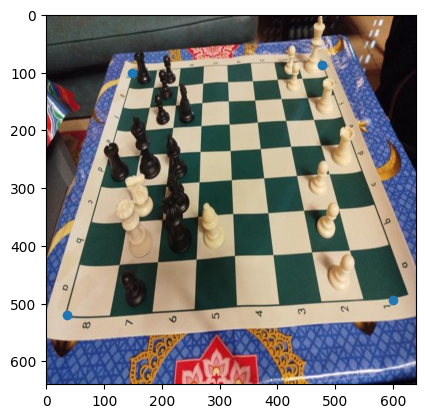

In [40]:
plt.imshow(img.img.permute(1,2,0));
plt.scatter(corners_up_2d[:,0], corners_up_2d[:,1]);

In [41]:
img.recognize_pieces()

0: 640x640 1 black-bishop, 1 black-king, 2 black-knights, 4 black-pawns, 1 black-queen, 2 black-rooks, 1 white-bishop, 1 white-king, 1 white-knight, 5 white-pawns, 1 white-queen, 2 white-rooks, 115.2ms
Speed: 19.8ms preprocess, 115.2ms inference, 6.3ms postprocess per image at shape (1, 3, 640, 640)


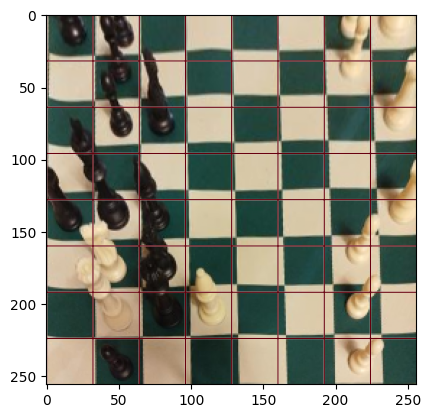

In [42]:
M = ChessLens.PieceDetection.piece_detector.piece_detector.M

warpped_img = cv2.warpPerspective(img.img.permute(1,2,0).numpy(), M.numpy(), (256,256))
plt.imshow(warpped_img);

grid = np.zeros((256,256))
grid[::32, :] = 1
grid[:, ::32] = 1
plt.imshow(grid, alpha = grid, cmap="Reds");

In [43]:
r = 2
c = 2

In [44]:
sq_box = np.array([
    [(c-1)*32, (r-1)*32],
    [(c)*32, (r-1)*32],
    [(c)*32, (r)*32],
    [(c-1)*32, (r)*32],
], dtype=np.float32)

In [45]:
M_inv = np.linalg.inv(M)

inverted_sq = []

for i in range(len(sq_box)):
    inverted_sq.append(M_inv @ np.concat([sq_box[i], np.ones(1)], axis=0))
    inverted_sq[-1] = (inverted_sq[-1] / inverted_sq[-1][2])[:2]

inverted_sq = np.stack(inverted_sq, axis=0)
inverted_sq

/tmp/ipykernel_36832/1142479384.py:6: DeprecationWarning: __array_wrap__ must accept context and return_scalar arguments (positionally) in the future. (Deprecated NumPy 2.0)
  inverted_sq.append(M_inv @ np.concat([sq_box[i], np.ones(1)], axis=0))


array([[     182.95,      131.31],
       [     226.51,      129.32],
       [     221.93,      165.11],
       [     175.84,      167.23]])

In [46]:
pts = trace_ray(from_2d_to_3d(inverted_sq, K, R), cam_point, np.zeros(4)) + np.concat([np.zeros((4,2)), .1*np.ones((4,1))], axis=1)
pts2 = from_3d_to_2d(pts, K, R)

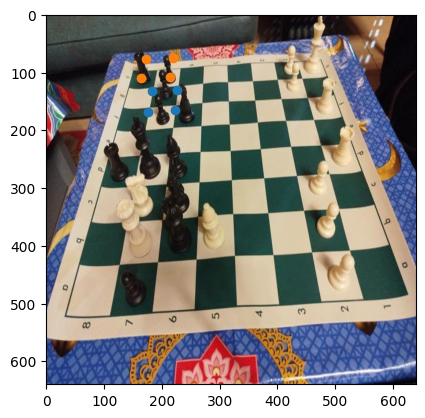

In [47]:
plt.imshow(img.img.permute(1,2,0));
plt.scatter(inverted_sq[:,0], inverted_sq[:,1]);
plt.scatter(pts2[:,0], pts2[:,1]);

In [48]:
xs = np.linspace(0,256, 9)
ys = np.linspace(0,256, 9)

X, Y = np.meshgrid(xs, ys)
points = np.stack([X,Y], axis=2)

points.shape, X.shape, Y.shape, points[3,6]

((9, 9, 2), (9, 9), (9, 9), array([        192,          96]))

In [49]:
tmp = np.concat([points, np.ones((9,9,1))], axis=2) @ M_inv.numpy().T

tmp = (tmp/tmp[:, :, [2]])[:, :, :2].reshape(-1, 2)
tmp

array([[        148,         101],
       [     189.32,      99.122],
       [     230.62,      97.245],
       [      271.9,      95.368],
       [     313.16,      93.493],
       [      354.4,      91.618],
       [     395.62,      89.745],
       [     436.82,      87.872],
       [        478,          86],
       [     139.37,       133.3],
       [     182.95,      131.31],
       [     226.51,      129.32],
       [     270.05,      127.34],
       [     313.57,      125.35],
       [     357.06,      123.36],
       [     400.54,      121.38],
       [     443.99,       119.4],
       [     487.42,      117.41],
       [     129.73,      169.34],
       [     175.84,      167.23],
       [     221.93,      165.11],
       [     267.99,         163],
       [     314.03,      160.89],
       [     360.04,      158.78],
       [     406.02,      156.67],
       [     451.98,      154.57],
       [     497.92,      152.46],
       [     118.91,      209.82],
       [     167.86,

In [50]:
elevated_tmp = trace_ray(from_2d_to_3d(tmp, K, R), cam_point, np.zeros((81)))
elevated_tmp += np.concat([np.zeros((81,2)), .1*np.ones((81, 1))], axis=1)
elevated_tmp = from_3d_to_2d(elevated_tmp, K, R)
elevated_tmp

array([[     136.59,      47.987],
       [      180.7,      46.279],
       [     224.75,      44.573],
       [     268.76,      42.869],
       [     312.72,      41.167],
       [     356.62,      39.467],
       [     400.47,      37.769],
       [     444.27,      36.073],
       [     488.02,      34.379],
       [     126.23,      77.546],
       [     173.04,      75.715],
       [     219.79,      73.887],
       [     266.48,      72.061],
       [     313.11,      70.237],
       [     359.69,      68.416],
       [      406.2,      66.596],
       [     452.66,      64.779],
       [     499.07,      62.965],
       [     114.52,      110.95],
       [     164.38,      108.98],
       [     214.17,      107.01],
       [      263.9,      105.04],
       [     313.56,      103.08],
       [     363.15,      101.12],
       [     412.68,      99.158],
       [     462.14,      97.202],
       [     511.54,      95.248],
       [     101.19,         149],
       [     154.52,

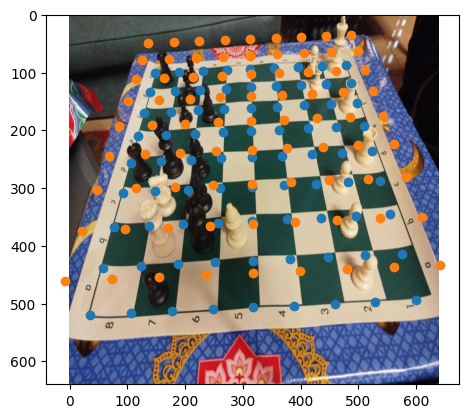

In [51]:
plt.imshow(img.img.permute(1,2,0));
plt.scatter(tmp[:,0], tmp[:,1]);
plt.scatter(elevated_tmp[:,0], elevated_tmp[:,1]);